# 02 — CNN + Batch Normalization on CIFAR-10

**Project:** Progressive CNN Classifier Study
**Stage:** 2 of 6 — Adding Batch Normalization

### Goal
Take the exact same architecture from `01_baseline_cnn.ipynb` and add a `BatchNormalization()` layer after every Conv2D layer (before the activation... in Keras we apply it right after Conv2D, before pooling). Compare results directly against the baseline.

### Baseline to beat (from Notebook 01)
- **Test Accuracy:** 0.7166
- **Test Loss:** 0.8821

### What is Batch Normalization?
For each mini-batch, BatchNorm normalizes the activations of a layer to have mean ≈ 0 and variance ≈ 1, then applies a learnable scale (`gamma`) and shift (`beta`). This helps because:
- **Stabilizes training** — reduces "internal covariate shift" (activation distributions changing wildly layer to layer as weights update).
- **Allows higher learning rates** — training converges faster.
- **Mild regularization effect** — the batch statistics add a small amount of noise, similar in spirit (not magnitude) to Dropout.

### What this notebook covers
- Inserting BatchNorm layers into a CNN
- Training under identical conditions to the baseline (same epochs, batch size, optimizer)
- Comparing accuracy/loss curves and final metrics against Notebook 01

## 1. Imports

In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


## 2. Load and Preprocess CIFAR-10

Identical preprocessing to Notebook 01 — normalize pixels to [0, 1]. Keeping this identical is what makes the comparison to the baseline fair.

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 3. Build the CNN + BatchNorm

**Only change vs. Notebook 01:** a `BatchNormalization()` layer is inserted right after every `Conv2D` layer, before pooling. Everything else (number of layers, filter counts, dense head) is kept identical so BatchNorm is the *only* variable being tested.

In [3]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

/Users/adityagupta/Desktop/Machine learning/GDenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,210 (481.29 KB)

 Trainable params: 122,890 (480.04 KB)

 Non-trainable params: 320 (1.25 KB)

Notice in the summary: BatchNorm adds a small number of extra trainable parameters per layer (`gamma` and `beta`), plus non-trainable ones (moving mean/variance used at inference time). This is a very small parameter cost for a often-significant training stability benefit.

## 4. Compile

Same optimizer, loss, and metric as the baseline — keeping every other setting identical isolates BatchNorm's effect.

In [4]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 5. Train

Same 15 epochs, batch size 64, and validation data as the baseline for a fair, apples-to-apples comparison.

In [5]:
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5328 - loss: 1.3324 - val_accuracy: 0.5109 - val_loss: 1.4455
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6726 - loss: 0.9359 - val_accuracy: 0.6166 - val_loss: 1.0929
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7261 - loss: 0.7829 - val_accuracy: 0.5942 - val_loss: 1.2126
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7610 - loss: 0.6827 - val_accuracy: 0.6784 - val_loss: 0.9664
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7912 - loss: 0.5946 - val_accuracy: 0.6566 - val_loss: 1.0596
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8136 - loss: 0.5270 - val_accuracy: 0.6053 - val_loss: 1.4605
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8366 - loss: 0.4647 - val_accuracy: 0.6785 - val_loss: 1.0445
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8548 - loss: 0.4081 - val_acc

## 6. Save the Model

In [6]:
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

model.save("models/batchnorm_cnn.h5")
print("Model saved to models/batchnorm_cnn.h5")

Model saved to models/batchnorm_cnn.h5


## 7. Visualize Training Curves

Compare this shape to Notebook 01's plots (open both side by side). With BatchNorm you typically see:
- Faster initial convergence (accuracy rises more quickly in early epochs)
- A smoother, less noisy loss curve

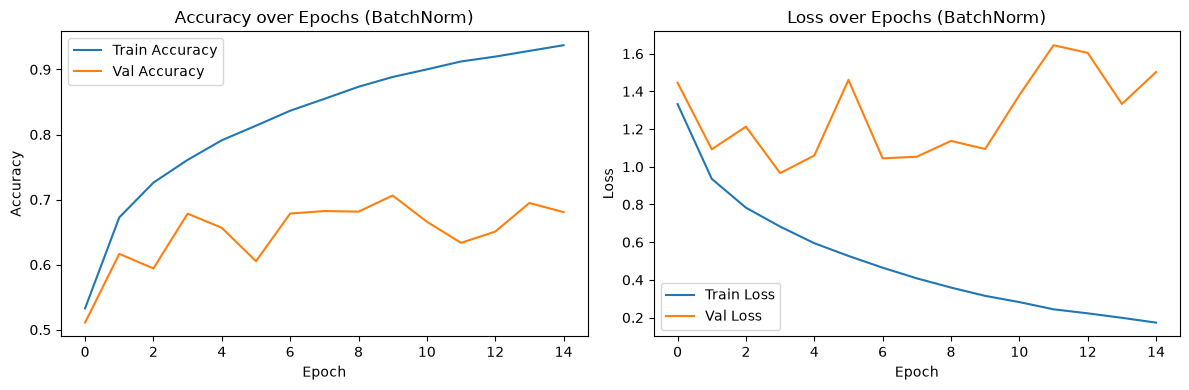

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy over Epochs (BatchNorm)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss over Epochs (BatchNorm)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("results/batchnorm_cnn_curves.png")
plt.show()

## 8. Final Evaluation

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6807 - loss: 1.5024
Final Test Accuracy: 0.6807
Final Test Loss: 1.5024


## 9. Direct Comparison vs. Baseline

Fill this in after running both notebooks — this table is exactly what should go in your project report.

In [9]:
baseline_acc = 0.7166
baseline_loss = 0.8821

print(f"{'Model':<20}{'Test Accuracy':<18}{'Test Loss':<12}")
print(f"{'Baseline (01)':<20}{baseline_acc:<18.4f}{baseline_loss:<12.4f}")
print(f"{'BatchNorm (02)':<20}{test_acc:<18.4f}{test_loss:<12.4f}")
print(f"\nAccuracy change: {test_acc - baseline_acc:+.4f}")
print(f"Loss change: {test_loss - baseline_loss:+.4f}")

Model               Test Accuracy     Test Loss   
Baseline (01)       0.7166            0.8821      
BatchNorm (02)      0.6807            1.5024      

Accuracy change: -0.0359
Loss change: +0.6203


## Summary & Next Steps

| Notebook | Technique Added | Test Accuracy |
|---|---|---|
| 01 | None (baseline) | 0.7166 |
| 02 (this one) | + Batch Normalization | *fill in after running* |
| 03 | + Dropout | TBD |
| 04 | + Data Augmentation | TBD |
| 05 | + LR Scheduling | TBD |
| 06 | Transfer Learning (ResNet/VGG) | TBD |

**Interpretation tip for your report:** if accuracy went up and/or the train/val gap shrank compared to Notebook 01, BatchNorm helped both speed and generalization. If accuracy is roughly the same but the curves are smoother/converge faster, that's still a meaningful result worth reporting — BatchNorm's main promise is training stability, not necessarily a large accuracy jump on its own.

**Next:** proceed to `03_dropout.ipynb`, where we add Dropout layers to directly target overfitting (the train/val accuracy gap).